In [1]:
!pip install nltk wordcloud seaborn NRCLex -q


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import random

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud
from nrclex import NRCLex

from collections import Counter

nltk.download("vader_lexicon")

print("Libraries imported successfully.")

Libraries imported successfully.


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


## 1. Dataset and Data Preparation

The e-commerce dataset is loaded and examined to understand its
structure, columns, data types, and missing values.

Because the original dataset contains sales information but no
customer comments, a review-text column will be created for
demonstration purposes.

In [3]:
file_path = "ecommerce_sales_1.1_millions_records.csv"

df = pd.read_csv(
    file_path,
    parse_dates=["Date"]
)

print("Dataset loaded successfully.")
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

display(df.head())

Dataset loaded successfully.
Number of rows: 1100000
Number of columns: 7


,Order_ID,Product,Category,Quantity,Price,City,Date
0,ORD0000001,Smartphone,Electronics,3,13376,Jaipur,2026-05-31
1,ORD0000002,Bedsheet,Home & Living,5,1979,Bengaluru,2024-11-02
2,ORD0000003,Coffee Maker,Home Appliances,5,3061,Ahmedabad,2026-04-25
3,ORD0000004,Shoes,Footwear,3,1551,Nagpur,2026-08-08
4,ORD0000005,Shoes,Footwear,3,1537,Jaipur,2024-12-27


In [4]:
sample_size = 30000

review_df = df.sample(
    n=min(sample_size, len(df)),
    random_state=42
).copy()

review_df.reset_index(drop=True, inplace=True)

print("Records selected for sentiment analysis:", len(review_df))

display(
    review_df[
        ["Order_ID", "Product", "Category", "City", "Date"]
    ].head()
)

Records selected for sentiment analysis: 30000


,Order_ID,Product,Category,City,Date
0,ORD0255969,Laptop,Electronics,Patna,2024-09-13
1,ORD0780984,Mixer Grinder,Home Appliances,Kolkata,2025-07-31
2,ORD0214663,Bedsheet,Home & Living,Nagpur,2024-10-07
3,ORD0339423,Books,Books,Lucknow,2026-07-17
4,ORD0634691,Coffee Maker,Home Appliances,Bhopal,2025-08-15


In [5]:
positive_reviews = [
    "I really love this product. It works perfectly and the quality is excellent.",
    "Excellent product and very good quality. I am completely satisfied.",
    "Amazing purchase. The product works very well and I would recommend it.",
    "Very happy with this purchase. The quality is great.",
    "This product is fantastic and performs really well.",
    "Great quality product. I am very satisfied with my purchase.",
    "The product is reliable, useful and worth the money.",
    "I am impressed with the quality and performance.",
    "Wonderful product. Everything works perfectly.",
    "Very good purchase. I am happy with the product."
]

negative_reviews = [
    "I am very disappointed with this product. The quality is poor.",
    "Terrible product. It does not work properly.",
    "Very bad experience. The product quality is disappointing.",
    "I regret buying this product. It has several problems.",
    "Poor quality and disappointing performance.",
    "The product stopped working and I am unhappy with the purchase.",
    "Not worth the money. The quality is very poor.",
    "I expected much better quality from this product.",
    "The product has many issues and I am not satisfied.",
    "Very disappointing purchase. I would not recommend it."
]

neutral_reviews = [
    "The product is okay and works as expected.",
    "The product is average and performs normally.",
    "It is a standard product with normal performance.",
    "The product works and meets basic expectations.",
    "The quality is acceptable for regular use.",
    "This is an ordinary product with average performance.",
    "The product is neither excellent nor poor.",
    "It works as described with average quality.",
    "The product is suitable for normal use.",
    "Overall, the product is satisfactory."
]

random.seed(42)

def generate_review(product):
    sentiment_type = random.choices(
        ["positive", "negative", "neutral"],
        weights=[0.55, 0.25, 0.20],
        k=1
    )[0]

    if sentiment_type == "positive":
        return random.choice(positive_reviews)

    elif sentiment_type == "negative":
        return random.choice(negative_reviews)

    else:
        return random.choice(neutral_reviews)


review_df["Review_Text"] = review_df["Product"].apply(generate_review)

display(
    review_df[
        ["Product", "Category", "Review_Text"]
    ].head(10)
)

,Product,Category,Review_Text
0,Laptop,Electronics,I am very disappointed with this product. The ...
1,Mixer Grinder,Home Appliances,I regret buying this product. It has several p...
2,Bedsheet,Home & Living,Excellent product and very good quality. I am ...
3,Books,Books,The product has many issues and I am not satis...
4,Coffee Maker,Home Appliances,"The product is reliable, useful and worth the ..."
5,Books,Books,Excellent product and very good quality. I am ...
6,Curtains,Home & Living,Wonderful product. Everything works perfectly.
7,Mixer Grinder,Home Appliances,The product has many issues and I am not satis...
8,Smartphone,Electronics,Wonderful product. Everything works perfectly.
9,Jeans,Clothing,I am impressed with the quality and performance.


In [6]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


review_df["Clean_Text"] = review_df["Review_Text"].apply(clean_text)

display(
    review_df[
        ["Review_Text", "Clean_Text"]
    ].head(10)
)

,Review_Text,Clean_Text
0,I am very disappointed with this product. The ...,i am very disappointed with this product the q...
1,I regret buying this product. It has several p...,i regret buying this product it has several pr...
2,Excellent product and very good quality. I am ...,excellent product and very good quality i am c...
3,The product has many issues and I am not satis...,the product has many issues and i am not satis...
4,"The product is reliable, useful and worth the ...",the product is reliable useful and worth the m...
5,Excellent product and very good quality. I am ...,excellent product and very good quality i am c...
6,Wonderful product. Everything works perfectly.,wonderful product everything works perfectly
7,The product has many issues and I am not satis...,the product has many issues and i am not satis...
8,Wonderful product. Everything works perfectly.,wonderful product everything works perfectly
9,I am impressed with the quality and performance.,i am impressed with the quality and performance


## 2. Sentiment Analysis Using NLP

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a
lexicon-based sentiment-analysis tool.

It produces a compound sentiment score between -1 and +1.
The score is used to classify each review as Positive, Negative,
or Neutral.

In [7]:
sia = SentimentIntensityAnalyzer()

review_df["Sentiment_Score"] = review_df["Review_Text"].apply(
    lambda text: sia.polarity_scores(text)["compound"]
)

display(
    review_df[
        ["Review_Text", "Sentiment_Score"]
    ].head(10)
)

,Review_Text,Sentiment_Score
0,I am very disappointed with this product. The ...,-0.7574
1,I regret buying this product. It has several p...,-0.6705
2,Excellent product and very good quality. I am ...,0.8746
3,The product has many issues and I am not satis...,-0.3252
4,"The product is reliable, useful and worth the ...",0.5859
5,Excellent product and very good quality. I am ...,0.8746
6,Wonderful product. Everything works perfectly.,0.8360
7,The product has many issues and I am not satis...,-0.3252
8,Wonderful product. Everything works perfectly.,0.8360
9,I am impressed with the quality and performance.,0.4767


In [8]:
def classify_sentiment(score):

    if score >= 0.05:
        return "Positive"

    elif score <= -0.05:
        return "Negative"

    else:
        return "Neutral"


review_df["Sentiment"] = review_df["Sentiment_Score"].apply(
    classify_sentiment
)

display(
    review_df[
        [
            "Product",
            "Review_Text",
            "Sentiment_Score",
            "Sentiment"
        ]
    ].head(15)
)

,Product,Review_Text,Sentiment_Score,Sentiment
0,Laptop,I am very disappointed with this product. The ...,-0.7574,Negative
1,Mixer Grinder,I regret buying this product. It has several p...,-0.6705,Negative
2,Bedsheet,Excellent product and very good quality. I am ...,0.8746,Positive
3,Books,The product has many issues and I am not satis...,-0.3252,Negative
4,Coffee Maker,"The product is reliable, useful and worth the ...",0.5859,Positive
5,Books,Excellent product and very good quality. I am ...,0.8746,Positive
6,Curtains,Wonderful product. Everything works perfectly.,0.8360,Positive
7,Mixer Grinder,The product has many issues and I am not satis...,-0.3252,Negative
8,Smartphone,Wonderful product. Everything works perfectly.,0.8360,Positive
9,Jeans,I am impressed with the quality and performance.,0.4767,Positive


In [9]:
sentiment_counts = review_df["Sentiment"].value_counts()

sentiment_percentage = (
    review_df["Sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Sentiment Counts:")
display(sentiment_counts)

print("\nSentiment Percentage:")
display(sentiment_percentage)

Sentiment Counts:


Sentiment
Positive    19098
Negative     7400
Neutral      3502
Name: count, dtype: int64


Sentiment Percentage:


Sentiment
Positive    63.66
Negative    24.67
Neutral     11.67
Name: proportion, dtype: float64

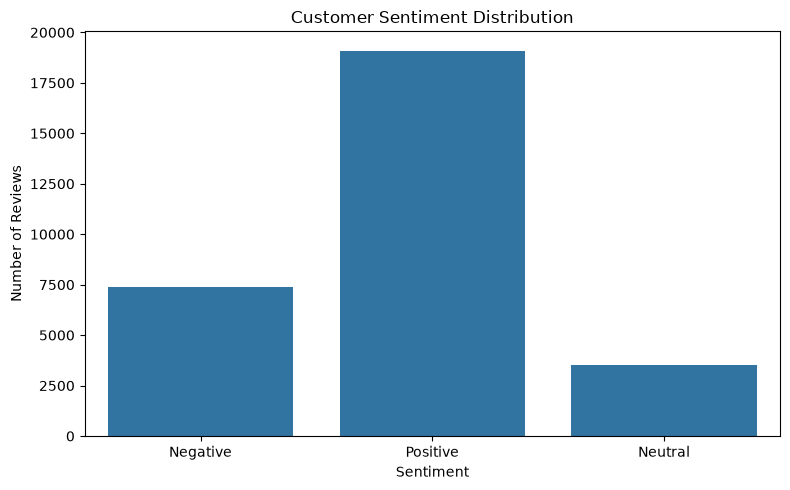

In [10]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=review_df,
    x="Sentiment"
)

plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

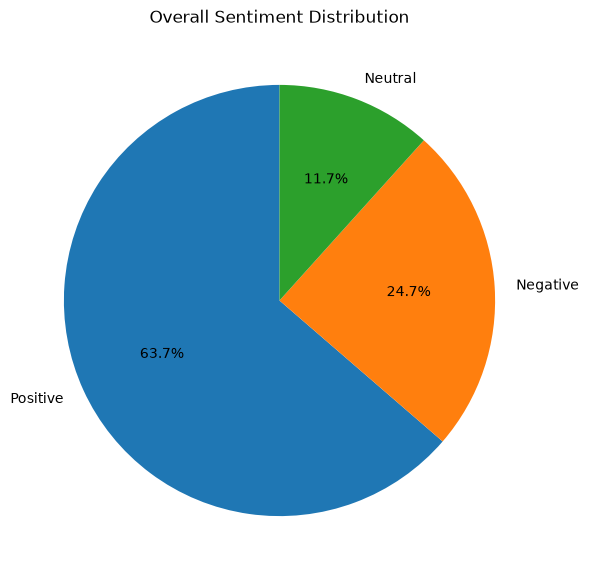

In [11]:
plt.figure(figsize=(7, 7))

plt.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Overall Sentiment Distribution")

plt.show()

## 3. Emotion Detection Using a Lexicon

In addition to Positive, Negative, and Neutral sentiment,
emotion analysis is performed using the NRC emotion lexicon.

The analysis identifies emotions such as joy, sadness, anger,
fear, surprise, disgust, trust, and anticipation.

In [12]:
# Check available NRCLex attributes

from nrclex import NRCLex

test_emotion = NRCLex("I am happy and excited.")

print([
    attr for attr in dir(test_emotion)
    if not attr.startswith("_")
])

['load_raw_text', 'load_token_list']


In [13]:
# Emotion Detection Using a Custom Emotion Lexicon

emotion_lexicon = {
    "Joy": [
        "happy", "love", "excellent", "amazing", "fantastic",
        "wonderful", "great", "impressed", "satisfied", "good"
    ],
    "Sadness": [
        "sad", "disappointed", "unhappy", "regret", "poor",
        "disappointing"
    ],
    "Anger": [
        "angry", "annoyed", "furious", "hate", "terrible"
    ],
    "Fear": [
        "fear", "afraid", "worried", "scared", "concern"
    ],
    "Trust": [
        "reliable", "trust", "dependable", "safe"
    ],
    "Surprise": [
        "surprised", "unexpected", "amazed", "astonished"
    ],
    "Disgust": [
        "awful", "horrible", "disgusting"
    ],
    "Anticipation": [
        "hope", "expect", "looking forward", "anticipate"
    ]
}


def detect_emotion(text):
    text = str(text).lower()

    emotion_scores = {}

    for emotion, keywords in emotion_lexicon.items():
        score = sum(
            text.count(keyword)
            for keyword in keywords
        )

        if score > 0:
            emotion_scores[emotion] = score

    if not emotion_scores:
        return "No Emotion Detected"

    return max(
        emotion_scores,
        key=emotion_scores.get
    )


review_df["Emotion"] = review_df["Review_Text"].apply(
    detect_emotion
)

display(
    review_df[
        ["Review_Text", "Sentiment", "Emotion"]
    ].head(15)
)

,Review_Text,Sentiment,Emotion
0,I am very disappointed with this product. The ...,Negative,Sadness
1,I regret buying this product. It has several p...,Negative,Sadness
2,Excellent product and very good quality. I am ...,Positive,Joy
3,The product has many issues and I am not satis...,Negative,Joy
4,"The product is reliable, useful and worth the ...",Positive,Trust
5,Excellent product and very good quality. I am ...,Positive,Joy
6,Wonderful product. Everything works perfectly.,Positive,Joy
7,The product has many issues and I am not satis...,Negative,Joy
8,Wonderful product. Everything works perfectly.,Positive,Joy
9,I am impressed with the quality and performance.,Positive,Joy


In [14]:
# Display Emotion Distribution

emotion_counts = review_df["Emotion"].value_counts()

print("Emotion Distribution:")
display(emotion_counts)

Emotion Distribution:


Emotion
Joy                    16933
Sadness                 4524
No Emotion Detected     4126
Anticipation            1931
Trust                   1742
Anger                    744
Name: count, dtype: int64

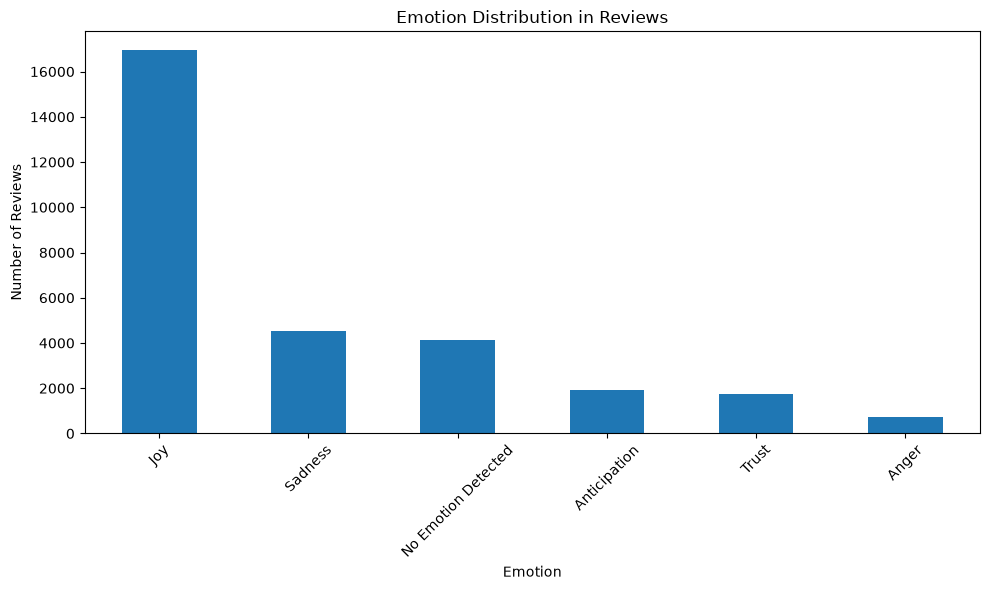

In [15]:
# Visualize Emotion Distribution

plt.figure(figsize=(10, 6))

emotion_counts.plot(kind="bar")

plt.title("Emotion Distribution in Reviews")
plt.xlabel("Emotion")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Sentiment Patterns and Trends

The sentiment results are analyzed across products, categories,
and time to identify customer-opinion patterns and trends.

In [16]:
category_sentiment = pd.crosstab(
    review_df["Category"],
    review_df["Sentiment"],
    normalize="index"
) * 100

category_sentiment = category_sentiment.round(2)

display(category_sentiment)

Sentiment,Negative,Neutral,Positive
Category,,,
Accessories,23.89,11.50,64.61
Books,24.52,12.62,62.85
Clothing,25.48,12.18,62.34
Electronics,24.93,11.72,63.35
Footwear,23.79,12.27,63.95
Furniture,23.88,12.05,64.07
Home & Living,24.99,11.61,63.40
Home Appliances,25.32,9.62,65.06
Kitchen,24.04,11.55,64.41


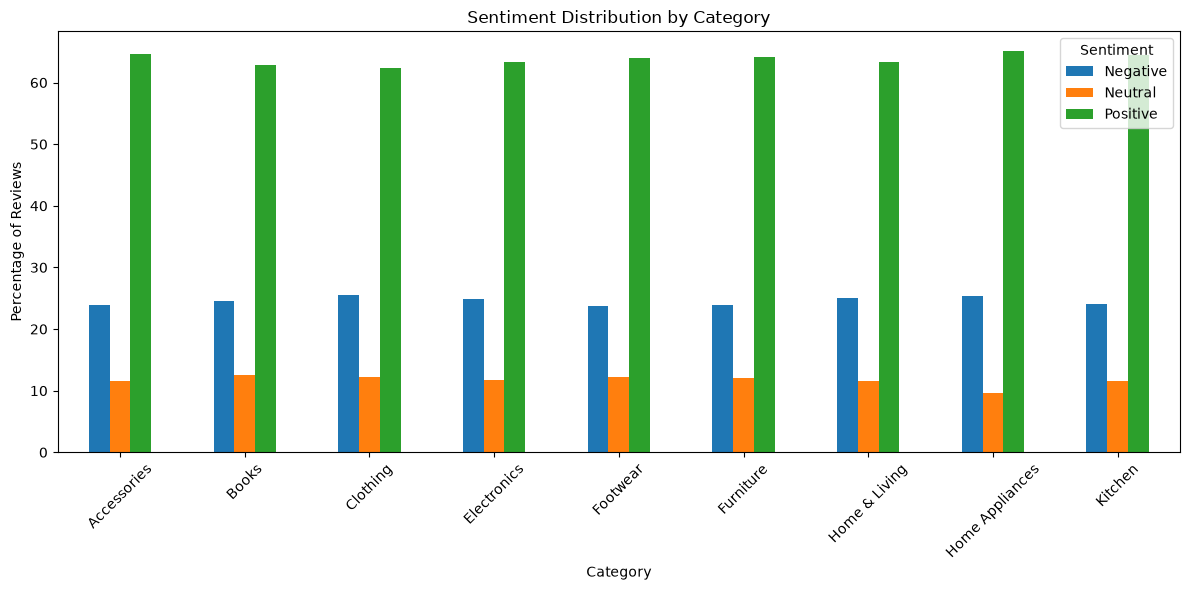

In [17]:
category_sentiment.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Sentiment Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Percentage of Reviews")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")

plt.tight_layout()
plt.show()

In [18]:
product_sentiment = (
    review_df
    .groupby("Product")["Sentiment_Score"]
    .mean()
    .sort_values(ascending=False)
)

display(product_sentiment)

Product
Backpack         0.326521
Study Table      0.324248
Mixer Grinder    0.312373
Shoes            0.307242
Tablet           0.305480
Cookware Set     0.304144
Headphones       0.302366
Coffee Maker     0.298750
Books            0.298314
Wallet           0.298227
Bedsheet         0.295452
Office Chair     0.293763
T-Shirt          0.292224
Sandals          0.290443
Smartphone       0.288142
Curtains         0.287696
Smart Watch      0.286087
Jacket           0.281924
Laptop           0.278618
Jeans            0.276144
Name: Sentiment_Score, dtype: float64

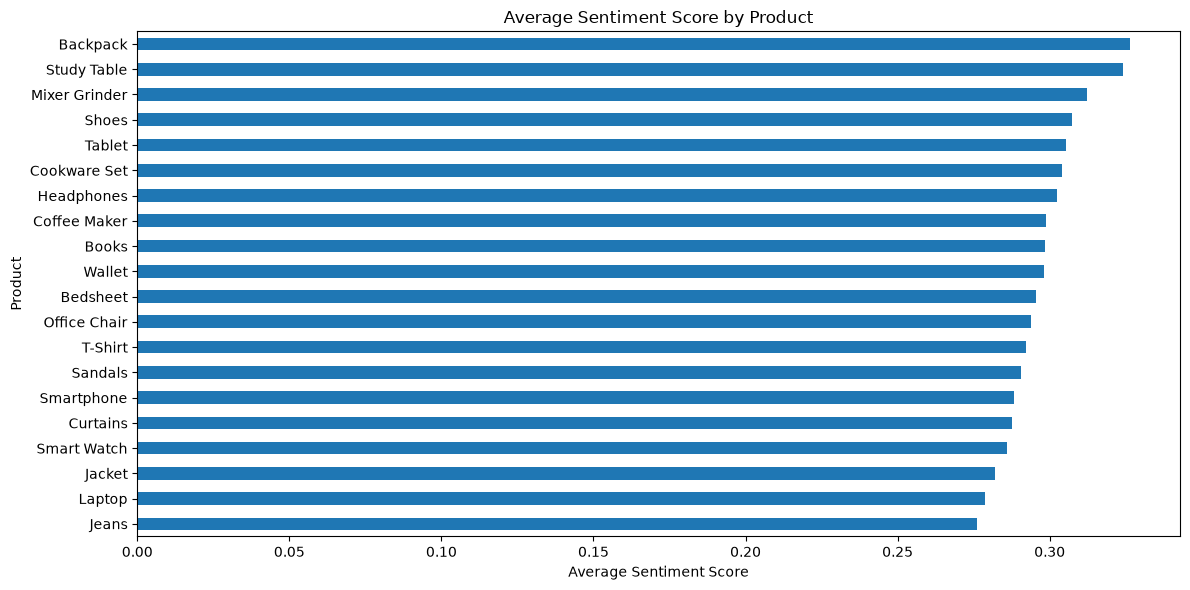

In [19]:
plt.figure(figsize=(12, 6))

product_sentiment.sort_values().plot(
    kind="barh"
)

plt.title("Average Sentiment Score by Product")
plt.xlabel("Average Sentiment Score")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [20]:
review_df["Month"] = (
    review_df["Date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_sentiment = (
    review_df
    .groupby(["Month", "Sentiment"])
    .size()
    .unstack(fill_value=0)
)

display(monthly_sentiment.head())

Sentiment,Negative,Neutral,Positive
Month,,,
2024-01,240,114,635
2024-02,235,91,603
2024-03,247,135,582
2024-04,217,105,594
2024-05,246,108,618


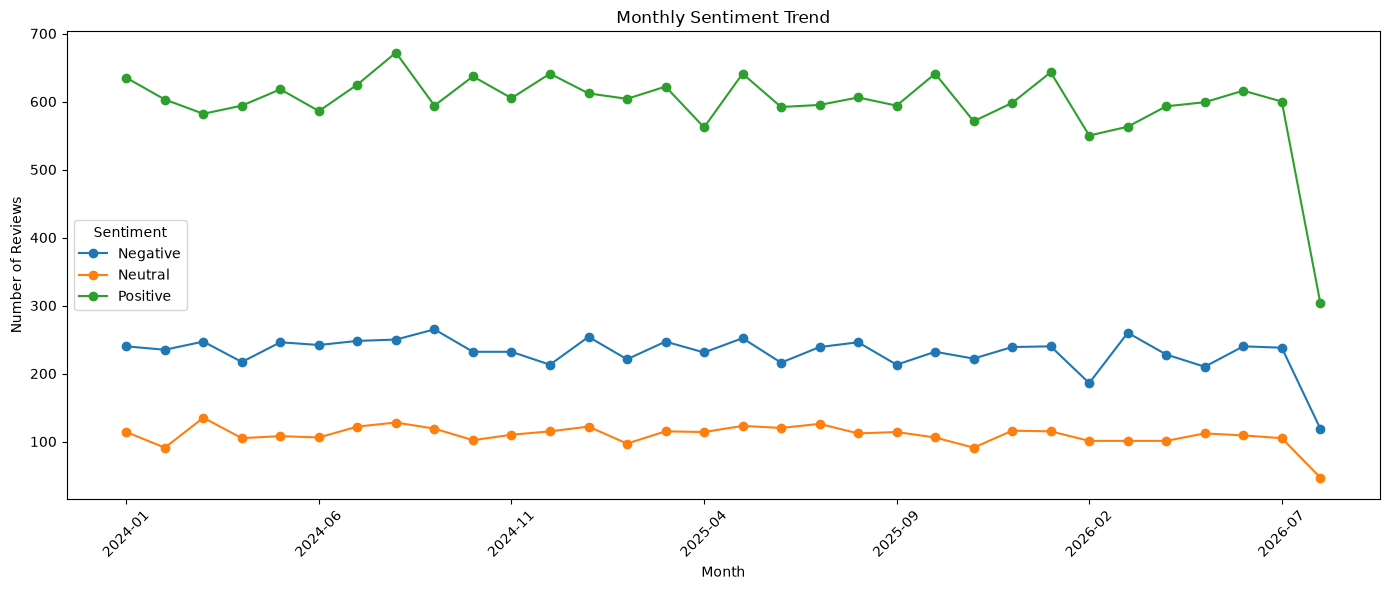

In [21]:
monthly_sentiment.plot(
    figsize=(14, 6),
    marker="o"
)

plt.title("Monthly Sentiment Trend")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")

plt.tight_layout()
plt.show()

In [22]:
all_words = " ".join(
    review_df["Clean_Text"]
)

words = all_words.split()

word_counts = Counter(words)

common_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["Word", "Frequency"]
)

display(common_words)

,Word,Frequency
0,product,23344
1,the,21116
2,i,14436
3,and,13942
4,is,13730
5,quality,13218
6,very,11355
7,with,9781
8,am,8876
9,purchase,8059


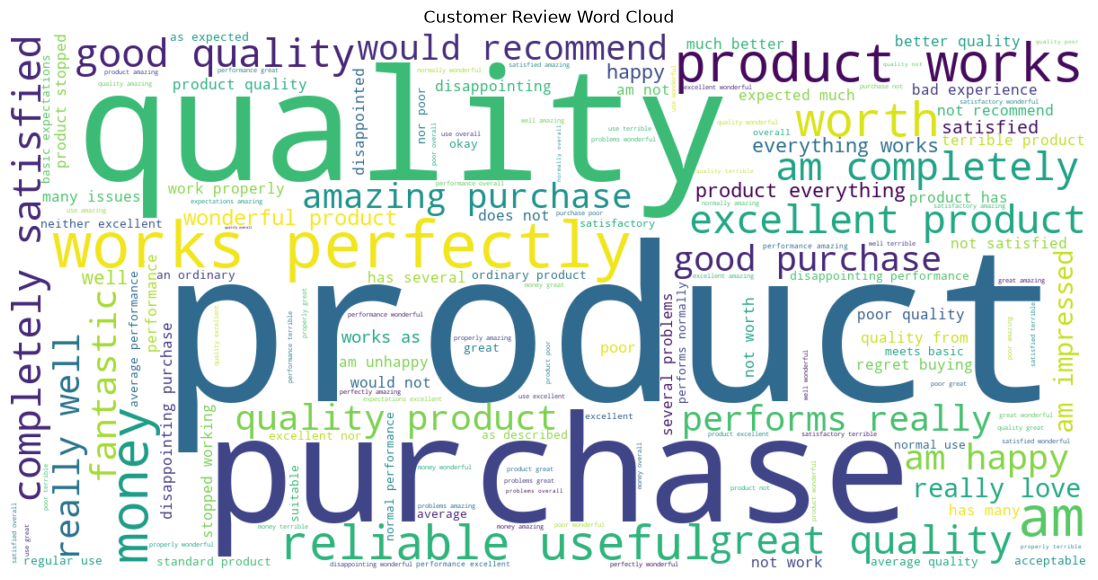

In [23]:
stop_words = {
    "the", "is", "and", "this", "a",
    "with", "for", "it", "i", "very",
    "to", "of", "my"
}

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=stop_words
).generate(all_words)

plt.figure(figsize=(14, 7))

plt.imshow(
    wordcloud,
    interpolation="bilinear"
)

plt.axis("off")

plt.title("Customer Review Word Cloud")

plt.show()

## 5. Business and Marketing Insights

Sentiment analysis can help businesses understand customer
opinions, identify products that may require improvement, and
support marketing decisions.

The following analysis identifies products with relatively
positive and negative sentiment scores.

In [24]:
most_positive = (
    review_df
    .groupby("Product")
    .agg(
        Average_Sentiment=("Sentiment_Score", "mean"),
        Number_of_Reviews=("Review_Text", "count")
    )
    .sort_values(
        "Average_Sentiment",
        ascending=False
    )
)

print("Most Positive Products:")
display(most_positive.head(10))

Most Positive Products:


,Average_Sentiment,Number_of_Reviews
Product,,
Backpack,0.326521,1530
Study Table,0.324248,1524
Mixer Grinder,0.312373,1478
Shoes,0.307242,1441
Tablet,0.305480,1545
Cookware Set,0.304144,1506
Headphones,0.302366,1512
Coffee Maker,0.298750,1464
Books,0.298314,1521


In [25]:
most_negative = (
    review_df
    .groupby("Product")
    .agg(
        Average_Sentiment=("Sentiment_Score", "mean"),
        Number_of_Reviews=("Review_Text", "count")
    )
    .sort_values(
        "Average_Sentiment",
        ascending=True
    )
)
print("Most Negative Products:")
display(most_negative.head(10))

Most Negative Products:


,Average_Sentiment,Number_of_Reviews
Product,,
Jeans,0.276144,1463
Laptop,0.278618,1475
Jacket,0.281924,1468
Smart Watch,0.286087,1611
Curtains,0.287696,1469
Smartphone,0.288142,1543
Sandals,0.290443,1502
T-Shirt,0.292224,1496
Office Chair,0.293763,1521


In [26]:
total_reviews = len(review_df)

positive_count = (
    review_df["Sentiment"] == "Positive"
).sum()

negative_count = (
    review_df["Sentiment"] == "Negative"
).sum()

neutral_count = (
    review_df["Sentiment"] == "Neutral"
).sum()

positive_pct = positive_count / total_reviews * 100
negative_pct = negative_count / total_reviews * 100
neutral_pct = neutral_count / total_reviews * 100

print("========== SENTIMENT ANALYSIS SUMMARY ==========")

print(f"Total Reviews: {total_reviews:,}")

print(
    f"Positive Reviews: {positive_count:,} "
    f"({positive_pct:.2f}%)"
)

print(
    f"Negative Reviews: {negative_count:,} "
    f"({negative_pct:.2f}%)"
)

print(
    f"Neutral Reviews: {neutral_count:,} "
    f"({neutral_pct:.2f}%)"
)

print(
    f"Average Sentiment Score: "
    f"{review_df['Sentiment_Score'].mean():.4f}"
)

========== SENTIMENT ANALYSIS SUMMARY ==========
Total Reviews: 30,000
Positive Reviews: 19,098 (63.66%)
Negative Reviews: 7,400 (24.67%)
Neutral Reviews: 3,502 (11.67%)
Average Sentiment Score: 0.2975


In [27]:
top_positive_product = most_positive.index[0]
top_negative_product = most_negative.index[0]

top_emotion = emotion_counts.index[0]

print("========== KEY INSIGHTS ==========\n")

print(
    f"1. Positive sentiment accounts for "
    f"{positive_pct:.2f}% of the analyzed reviews."
)

print(
    f"2. Negative sentiment accounts for "
    f"{negative_pct:.2f}% of the analyzed reviews."
)

print(
    f"3. Neutral sentiment accounts for "
    f"{neutral_pct:.2f}% of the analyzed reviews."
)

print(
    f"4. {top_positive_product} has the highest "
    f"average sentiment score."
)

print(
    f"5. {top_negative_product} has the lowest "
    f"average sentiment score."
)

print(
    f"6. The most frequently detected emotion is "
    f"{top_emotion}."
)

print(
    "7. Sentiment patterns can be used to identify "
    "customer preferences and areas for product improvement."
)

print(
    "8. Businesses can use positive sentiment for marketing "
    "and investigate negative sentiment to improve products "
    "and customer experience."
)

========== KEY INSIGHTS ==========

1. Positive sentiment accounts for 63.66% of the analyzed reviews.
2. Negative sentiment accounts for 24.67% of the analyzed reviews.
3. Neutral sentiment accounts for 11.67% of the analyzed reviews.
4. Backpack has the highest average sentiment score.
5. Jeans has the lowest average sentiment score.
6. The most frequently detected emotion is Joy.
7. Sentiment patterns can be used to identify customer preferences and areas for product improvement.
8. Businesses can use positive sentiment for marketing and investigate negative sentiment to improve products and customer experience.


## 6. Conclusion

The sentiment-analysis project demonstrates how Natural Language
Processing can be used to analyze customer-oriented text.

VADER was used to classify text into Positive, Negative, and
Neutral sentiment, while the NRC emotion lexicon was used to
identify emotion patterns.

The analysis also examined sentiment across products, categories,
and time. Visualizations such as bar charts, line charts, and
word clouds helped communicate the results clearly.

These insights can support marketing decisions, product
improvement, customer-feedback analysis, and business strategy.

Limitation: The supplied e-commerce dataset did not contain
actual customer review text. Synthetic review comments were
therefore used to demonstrate the NLP workflow. The resulting
sentiment scores should not be interpreted as real customer
opinions.

In [28]:
final_results = review_df[
    [
        "Order_ID",
        "Product",
        "Category",
        "City",
        "Date",
        "Review_Text",
        "Clean_Text",
        "Sentiment_Score",
        "Sentiment",
        "Emotion"
    ]
].copy()

final_results.to_csv(
    "sentiment_analysis_results.csv",
    index=False
)

print("Final results saved successfully!")
print("File: sentiment_analysis_results.csv")

display(final_results.head())

Final results saved successfully!
File: sentiment_analysis_results.csv


,Order_ID,Product,Category,City,Date,Review_Text,Clean_Text,Sentiment_Score,Sentiment,Emotion
0,ORD0255969,Laptop,Electronics,Patna,2024-09-13,I am very disappointed with this product. The ...,i am very disappointed with this product the q...,-0.7574,Negative,Sadness
1,ORD0780984,Mixer Grinder,Home Appliances,Kolkata,2025-07-31,I regret buying this product. It has several p...,i regret buying this product it has several pr...,-0.6705,Negative,Sadness
2,ORD0214663,Bedsheet,Home & Living,Nagpur,2024-10-07,Excellent product and very good quality. I am ...,excellent product and very good quality i am c...,0.8746,Positive,Joy
3,ORD0339423,Books,Books,Lucknow,2026-07-17,The product has many issues and I am not satis...,the product has many issues and i am not satis...,-0.3252,Negative,Joy
4,ORD0634691,Coffee Maker,Home Appliances,Bhopal,2025-08-15,"The product is reliable, useful and worth the ...",the product is reliable useful and worth the m...,0.5859,Positive,Trust


In [29]:
# Final Project Verification

print("========== TASK 4: SENTIMENT ANALYSIS ==========")

print("\n1. Dataset Shape:", review_df.shape)

print("\n2. Sentiment Distribution:")
print(review_df["Sentiment"].value_counts())

print("\n3. Emotion Distribution:")
print(review_df["Emotion"].value_counts())

print("\n4. Missing Review Text:",
      review_df["Review_Text"].isnull().sum())

print("\n5. Average Sentiment Score:",
      round(review_df["Sentiment_Score"].mean(), 3))

print("\nTask 4 verification completed!")

========== TASK 4: SENTIMENT ANALYSIS ==========

1. Dataset Shape: (30000, 13)

2. Sentiment Distribution:
Sentiment
Positive    19098
Negative     7400
Neutral      3502
Name: count, dtype: int64

3. Emotion Distribution:
Emotion
Joy                    16933
Sadness                 4524
No Emotion Detected     4126
Anticipation            1931
Trust                   1742
Anger                    744
Name: count, dtype: int64

4. Missing Review Text: 0

5. Average Sentiment Score: 0.297

Task 4 verification completed!


In [30]:
# Save Final Sentiment Analysis Results

review_df.to_csv(
    "sentiment_analysis_results.csv",
    index=False
)

print("Results saved successfully!")
print("File: sentiment_analysis_results.csv")

Results saved successfully!
File: sentiment_analysis_results.csv
